In [72]:
# ============================================
# Cell 1 — Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")

In [73]:
# ============================================
# Cell 2 — Load Processed RFM Data
# ============================================
import pandas as pd
import os

# --- 1. Path Configuration ---
# Use the same absolute path where we exported the data in the previous notebook
base_data_path = r"C:\Users\User\Desktop\bank-rfm-analysis\Data"
file_path = os.path.join(base_data_path, "processed", "rfm_segments.csv")

# --- 2. Load the Dataset ---
# Check if the file exists before loading to avoid FileNotFoundError
if os.path.exists(file_path):
    rfm = pd.read_csv(file_path)
    print(f"✅ Successfully loaded: {file_path}")
    print(f"Dataset Shape: {rfm.shape}")
else:
    print(f"❌ Error: The file was not found at {file_path}")

# --- 3. Statistical Summary ---
# Displaying descriptive statistics for the RFM metrics
rfm_stats = rfm[["recency_days", "frequency", "monetary"]].describe()
print("\n--- Descriptive Statistics ---")
print(rfm_stats)

✅ Successfully loaded: C:\Users\User\Desktop\bank-rfm-analysis\Data\processed\rfm_segments.csv
Dataset Shape: (4500, 16)

--- Descriptive Statistics ---
       recency_days    frequency      monetary
count   4500.000000  4500.000000  4.500000e+03
mean       2.599111   234.737778  6.270483e+05
std       30.625054   126.849443  5.845288e+05
min        0.000000     9.000000  1.400000e+03
25%        0.000000   133.000000  1.973261e+05
50%        0.000000   208.000000  4.133415e+05
75%        0.000000   330.000000  8.832919e+05
max      858.000000   675.000000  3.590676e+06


In [74]:
# ============================================
# Cell 3 — Feature Selection & Scaling
# ============================================

features = rfm[["recency_days", "frequency", "monetary"]].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print("Scaled shape:", X_scaled.shape)
print("Mean:", X_scaled.mean(axis=0).round(4))
print("Std: ", X_scaled.std(axis=0).round(4))

Scaled shape: (4500, 3)
Mean: [-0.  0.  0.]
Std:  [1. 1. 1.]


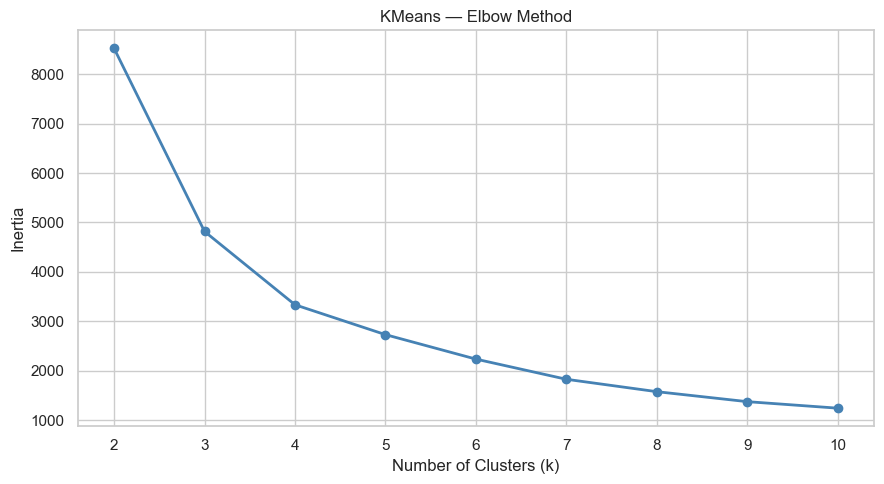

In [75]:
# ============================================
# Cell 4 — KMeans: Elbow Method
# ============================================

inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_range, inertias, marker="o", color="steelblue", linewidth=2)
plt.title("KMeans — Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

k=2  silhouette=0.4944
k=3  silhouette=0.5129
k=4  silhouette=0.4369
k=5  silhouette=0.4385
k=6  silhouette=0.4408
k=7  silhouette=0.4283
k=8  silhouette=0.3691
k=9  silhouette=0.3650
k=10  silhouette=0.3700


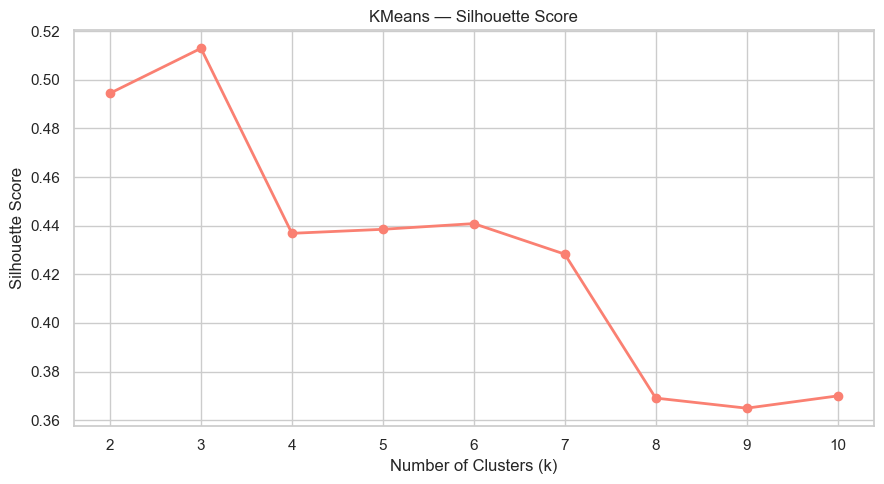

In [76]:
# ============================================
# Cell 5 — KMeans: Silhouette Scores
# ============================================

silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}  silhouette={score:.4f}")

plt.figure(figsize=(9, 5))
plt.plot(k_range, silhouette_scores, marker="o", color="salmon", linewidth=2)
plt.title("KMeans — Silhouette Score")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

In [77]:
# ============================================
# Cell 6 — KMeans: Final Model
# ============================================

BEST_K = 4

kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
rfm["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

print("KMeans cluster distribution:")
print(rfm["kmeans_cluster"].value_counts().sort_index())

KMeans cluster distribution:
kmeans_cluster
0    2228
1     727
2      12
3    1533
Name: count, dtype: int64


=== Segment Distribution (Ranked) ===
cluster_label
01. VIP / Champions        727
02. Loyal Customers       1533
03. Regular / Standard    2228
04. Lost / Churned          12
Name: count, dtype: int64

=== Final Segment Profiles (Mean Values) ===
                        recency_days  frequency    monetary
cluster_label                                              
01. VIP / Champions             0.61     403.16  1697830.20
02. Loyal Customers             0.35     305.86   619218.71
03. Regular / Standard          1.91     131.96   286288.44
04. Lost / Churned            539.17      27.33    23491.67


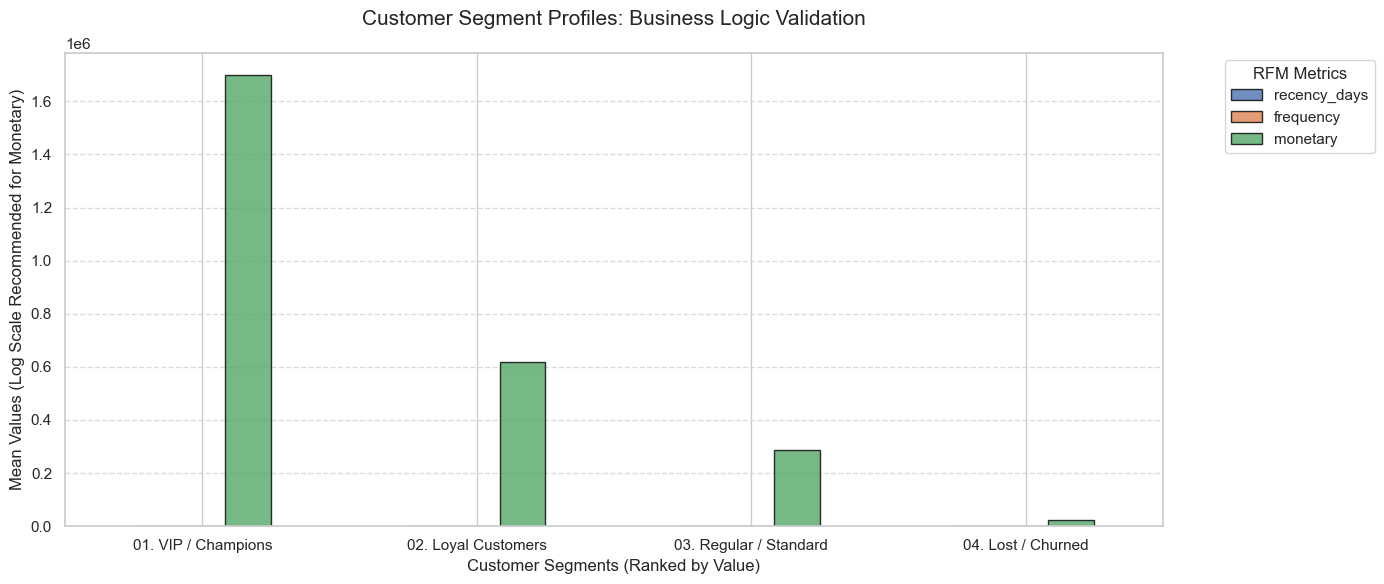

In [78]:
# ============================================
# Cell 13 — Final Cluster Labeling & Ranking
# ============================================

# Mapping numeric clusters to business-meaningful segments based on profiles:
# Cluster 1: Highest Monetary & Frequency -> 01. VIP / Champions
# Cluster 3: High Recency & Good Monetary -> 02. Loyal Customers
# Cluster 0: Average Frequency & Monetary -> 03. Regular / Standard
# Cluster 2: Very High Recency (539 days) -> 04. Lost / Churned

segment_mapping = {
    1: "01. VIP / Champions",
    3: "02. Loyal Customers",
    0: "03. Regular / Standard",
    2: "04. Lost / Churned"
}

# Apply the human-readable labels to the dataframe
rfm["cluster_label"] = rfm["kmeans_cluster"].map(segment_mapping)

# Display the customer distribution across the new named segments
print("=== Segment Distribution (Ranked) ===")
print(rfm["cluster_label"].value_counts().sort_index())

# Calculate and display the final mean values for each segment
# This confirms that the ranking aligns with business logic
final_segment_profile = rfm.groupby("cluster_label")[
    ["recency_days", "frequency", "monetary"]
].mean().round(2)

print("\n=== Final Segment Profiles (Mean Values) ===")
print(final_segment_profile)

# We use the 'final_segment_profile' created in Cell 13
# Sorting ensures the chart follows the 01 -> 04 business priority
plot_data = final_segment_profile.sort_index(ascending=True)

# Creating a multi-bar chart to compare R, F, M across segments
ax = plot_data.plot(
    kind="bar", 
    figsize=(14, 6), 
    edgecolor="black",
    alpha=0.8
)

# Adding professional titles and labels for the thesis report
plt.title("Customer Segment Profiles: Business Logic Validation", fontsize=15, pad=20)
plt.xlabel("Customer Segments (Ranked by Value)", fontsize=12)
plt.ylabel("Mean Values (Log Scale Recommended for Monetary)", fontsize=12)
plt.xticks(rotation=0) # Keeps labels horizontal for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="RFM Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')

# Optional: Using log scale for y-axis because Monetary is much larger than Recency
# plt.yscale('log') 

plt.tight_layout()
plt.show()

Explained variance: 55.28% + 32.55% = 87.83%


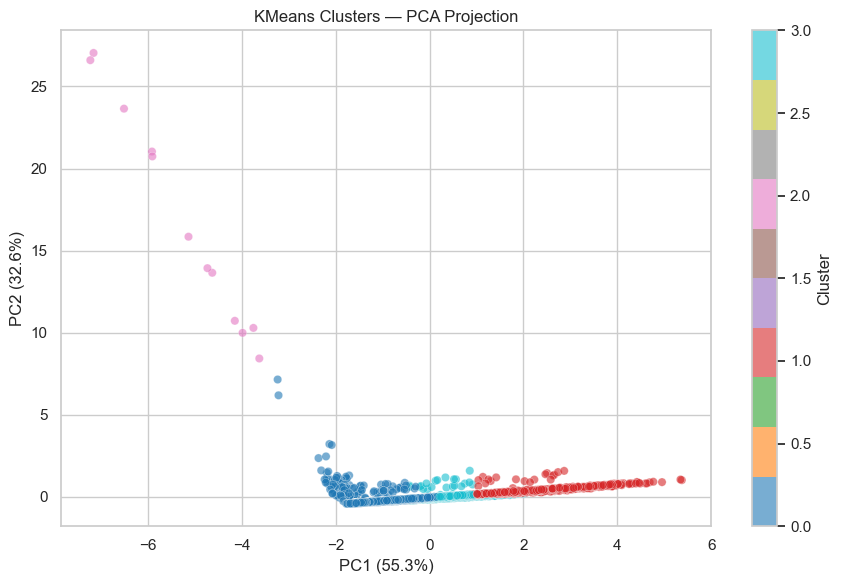

In [79]:
# ============================================
# Cell 8 — PCA Visualization (KMeans)
# ============================================

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f"Explained variance: {explained[0]:.2%} + {explained[1]:.2%} = {sum(explained):.2%}")

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=rfm["kmeans_cluster"],
    cmap="tab10",
    alpha=0.6,
    edgecolors="white",
    linewidths=0.3
)
plt.colorbar(scatter, label="Cluster")
plt.title("KMeans Clusters — PCA Projection")
plt.xlabel(f"PC1 ({explained[0]:.1%})")
plt.ylabel(f"PC2 ({explained[1]:.1%})")
plt.tight_layout()
plt.show()

In [80]:
# ============================================
# Cell 9 — DBSCAN
# ============================================

dbscan = DBSCAN(eps=0.5, min_samples=5)
rfm["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(rfm["dbscan_cluster"])) - (1 if -1 in rfm["dbscan_cluster"].values else 0)
n_noise    = (rfm["dbscan_cluster"] == -1).sum()

print(f"DBSCAN clusters found: {n_clusters}")
print(f"Noise points (-1):     {n_noise}")
print(rfm["dbscan_cluster"].value_counts().sort_index())

DBSCAN clusters found: 1
Noise points (-1):     37
dbscan_cluster
-1      37
 0    4463
Name: count, dtype: int64


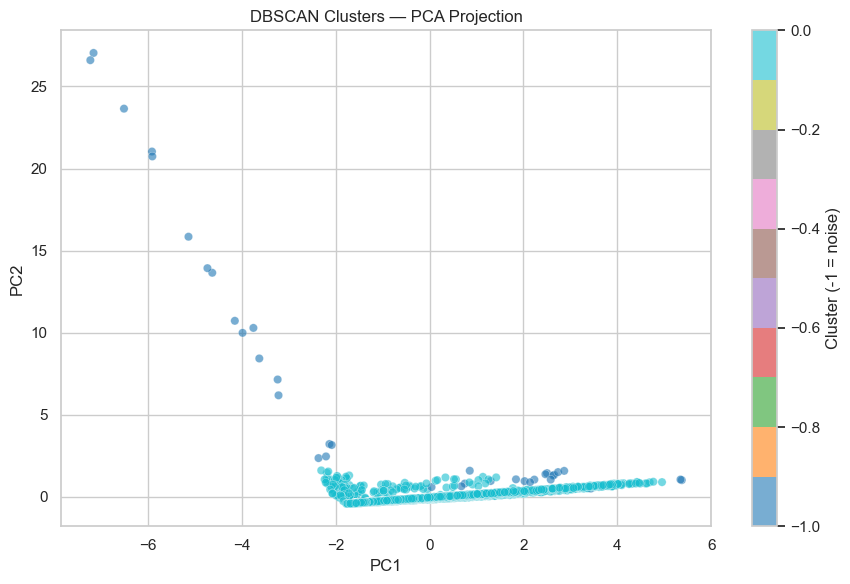

In [81]:
# ============================================
# Cell 10 — DBSCAN Visualization
# ============================================

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=rfm["dbscan_cluster"],
    cmap="tab10",
    alpha=0.6,
    edgecolors="white",
    linewidths=0.3
)
plt.colorbar(scatter, label="Cluster (-1 = noise)")
plt.title("DBSCAN Clusters — PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

In [82]:
# ============================================
# Cell 12 — Model Comparison
# ============================================

kmeans_score = silhouette_score(X_scaled, rfm["kmeans_cluster"])

mask = rfm["dbscan_cluster"] != -1
if mask.sum() > 1 and len(set(rfm.loc[mask, "dbscan_cluster"])) > 1:
    dbscan_score = silhouette_score(X_scaled[mask], rfm.loc[mask, "dbscan_cluster"])
else:
    dbscan_score = None

print("=== Silhouette Scores ===")
print(f"KMeans:        {kmeans_score:.4f}")
print(f"DBSCAN:        {dbscan_score if dbscan_score else 'N/A (too few clusters)'}")

=== Silhouette Scores ===
KMeans:        0.4369
DBSCAN:        N/A (too few clusters)


In [83]:
# ============================================
# Cell 13 — Final Cluster Labeling (Refined)
# ============================================

# Mapping based on the cluster profiles we analyzed:
cluster_labels = {
    1: "01. VIP / Champions",      # Top spending & frequency
    3: "02. Loyal Customers",      # Highly active & recent
    0: "03. Regular / Standard",   # Moderate activity
    2: "04. Lost / Churned"        # 500+ days inactive (Outliers)
}

rfm["cluster_label"] = rfm["kmeans_cluster"].map(cluster_labels)

print("=== Final Customer Segments ===")
print(rfm["cluster_label"].value_counts().sort_index())

=== Final Customer Segments ===
cluster_label
01. VIP / Champions        727
02. Loyal Customers       1533
03. Regular / Standard    2228
04. Lost / Churned          12
Name: count, dtype: int64


In [84]:
# ============================================
# Cell 15 — Final Export with Absolute Path
# ============================================
import os

# --- 1. Path Configuration ---
# Use the same absolute path to ensure files are saved in the correct project folder
base_data_path = r"C:\Users\User\Desktop\bank-rfm-analysis\Data"
output_path = os.path.join(base_data_path, "processed")

# Ensure the 'processed' directory exists
if not os.path.exists(output_path):
    os.makedirs(output_path)
    print(f"✅ Created directory: {output_path}")

# --- 2. Defining the Output Filename ---
# We save the final clustered data for Power BI or further analysis
final_export_file = os.path.join(output_path, "rfm_final_clustering_results.csv")

# --- 3. Export Execution ---
# Saving all columns including KMeans, DBSCAN, and Agglomerative labels
rfm.to_csv(final_export_file, index=False)

# --- 4. Final Summary ---
print("🚀 Clustering results exported successfully!")
print(f"Destination: {final_export_file}")
print(f"Final Shape: {rfm.shape}")
print(f"Available Columns: {list(rfm.columns)}")

# Verification of the first few rows to ensure labels are present
print("\n--- Preview of Cluster Labels ---")
print(rfm[['account_id', 'kmeans_cluster', 'cluster_label']].head())

🚀 Clustering results exported successfully!
Destination: C:\Users\User\Desktop\bank-rfm-analysis\Data\processed\rfm_final_clustering_results.csv
Final Shape: (4500, 19)
Available Columns: ['account_id', 'district_id', 'district_name', 'region', 'recency_days', 'frequency', 'monetary', 'r_score', 'f_score', 'm_score', 'rfm_score', 'rfm_string', 'segment', 'flag_hflv', 'flag_lfhv', 'flag_reactivation', 'kmeans_cluster', 'cluster_label', 'dbscan_cluster']

--- Preview of Cluster Labels ---
   account_id  kmeans_cluster        cluster_label
0         576               3  02. Loyal Customers
1        3818               1  01. VIP / Champions
2         704               1  01. VIP / Champions
3        2378               1  01. VIP / Champions
4        2632               1  01. VIP / Champions
